# Experiment 4: SPADE + Reference Encoder + Dual Discriminator

**Architecture:**
- **Reference Encoder:** CNN that extracts a style vector from the furniture image
- **Generator:** U-Net encoder (room image) + SPADE decoder (room-conditioned spatial norm) + AdaIN (furniture style injection)
- **Global Discriminator:** PatchGAN on full image (judges overall realism)
- **Local Discriminator:** PatchGAN on cropped furniture region (forces furniture to appear)

**Key improvements over Pix2Pix baseline:**
- Furniture is processed by a **separate encoder** (not smeared into input channels)
- **SPADE normalization** gives the decoder spatial awareness of room structure
- **AdaIN** injects furniture appearance at every decoder scale
- **Local discriminator** forces the model to actually place furniture (can't cheat by copying the room)
- **VGG perceptual loss** improves texture quality

**Input:** Room image (3ch) + Furniture image (3ch, separate encoder)  
**Output:** Furnished room (3ch)  
**Loss:** Hinge GAN (global + local) + 100 * L1 + 10 * VGG perceptual + 10 * Feature matching

**Discriminator stabilization (from original SPADE paper):**
- **Spectral Normalization** on all discriminator conv layers (constrains Lipschitz constant)
- **Hinge loss** instead of LSGAN (D stops optimizing once confident enough)
- **Feature matching loss** (G matches D's intermediate features, richer gradient signal)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import tensorflow as tf
from tensorflow.keras import layers

print(f'TensorFlow version: {tf.__version__}')
print(f'GPUs available: {len(tf.config.list_physical_devices("GPU"))}')

TensorFlow version: 2.19.0
GPUs available: 1


In [2]:
from google.colab import drive
drive.mount('/content/drive')

POSSIBLE_ROOTS = [
    '/content/drive/MyDrive/processed-256',
    '/content/drive/MyDrive/693-project/data/processed-256',
    '/content/drive/MyDrive/693-project/processed-256',
    '/content/drive/MyDrive/693 project/processed-256',
]

DATA_ROOT = None
for path in POSSIBLE_ROOTS:
    if os.path.isfile(os.path.join(path, 'metadata.csv')):
        DATA_ROOT = path
        break

if DATA_ROOT is None:
    print('Dataset not found. Add the shared folder as a Drive shortcut first.')
    raise FileNotFoundError('See instructions in cell above')

CSV_PATH = os.path.join(DATA_ROOT, 'metadata.csv')
print(f'Dataset root: {DATA_ROOT}')

CHECKPOINT_DIR = '/content/drive/MyDrive/693-project/checkpoints/spade_ref_tf_v2'
SAMPLE_DIR     = '/content/drive/MyDrive/693-project/samples/spade_ref_tf_v2'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(SAMPLE_DIR, exist_ok=True)

Mounted at /content/drive
Dataset root: /content/drive/MyDrive/processed-256


In [3]:
import shutil, time

LOCAL_DATA = '/content/local_data'
if not os.path.isdir(LOCAL_DATA):
    print('Copying dataset to local SSD...')
    t0 = time.time()
    shutil.copytree(DATA_ROOT, LOCAL_DATA)
    print(f'Done in {time.time() - t0:.0f}s')
else:
    print(f'Local copy exists at {LOCAL_DATA}')

DATA_ROOT = LOCAL_DATA
CSV_PATH = os.path.join(DATA_ROOT, 'metadata.csv')

for split in ['train', 'val', 'test']:
    n = len(os.listdir(os.path.join(DATA_ROOT, split, 'input')))
    print(f'  {split}/input: {n} files (local SSD)')

Copying dataset to local SSD...
Done in 270s
  train/input: 2994 files (local SSD)
  val/input: 370 files (local SSD)
  test/input: 354 files (local SSD)


In [4]:
IMG_SIZE     = 256
BATCH_SIZE   = 4
LR_G         = 1e-4
LR_D         = 4e-4
BETA1        = 0.0
BETA2        = 0.999
LAMBDA_L1    = 100
LAMBDA_PERC  = 10
LAMBDA_FEAT  = 10
STYLE_DIM    = 256
LOCAL_CROP   = 128
NUM_EPOCHS   = 200
SAVE_EPOCH   = 10
SAMPLE_EPOCH = 5

RESUME = False  # Fresh start — discriminator architecture changed

## Dataset

Same pipeline as Pix2Pix experiment. Each sample returns (room, target, furniture, bbox).  
- **room + furniture** go to the generator (via separate paths)  
- **bbox** is used only by the local discriminator to crop the furniture region

In [5]:
df = pd.read_csv(CSV_PATH)

def rebase_path(p):
    parts = p.replace('\\', '/').split('/')
    for i, part in enumerate(parts):
        if part in ('train', 'val', 'test'):
            return os.path.join(DATA_ROOT, *parts[i:])
    return p

for col in ['input_path', 'target_path', 'furniture_path']:
    df[col] = df[col].apply(rebase_path)

# Rescale bbox to stored image size if needed
sample_img = Image.open(df['target_path'].iloc[0])
stored_w, stored_h = sample_img.size
bbox_max = max(df['bbox_x2'].max(), df['bbox_y2'].max())

if bbox_max > max(stored_w, stored_h):
    src_dir = os.path.join(DATA_ROOT, 'src')
    orig_w, orig_h = None, None
    if os.path.isdir(src_dir):
        for f in sorted(os.listdir(src_dir)):
            fp = os.path.join(src_dir, f)
            if os.path.isfile(fp):
                try:
                    orig_w, orig_h = Image.open(fp).size
                    break
                except Exception:
                    continue
    if orig_w is None:
        orig_w = int(np.ceil(df['bbox_x2'].max() / 256) * 256)
        orig_h = int(np.ceil(df['bbox_y2'].max() / 256) * 256)
    df['bbox_x1'] *= stored_w / orig_w
    df['bbox_y1'] *= stored_h / orig_h
    df['bbox_x2'] *= stored_w / orig_w
    df['bbox_y2'] *= stored_h / orig_h
    print(f'Rescaled bboxes from {orig_w}x{orig_h} to {stored_w}x{stored_h}')

train_df = df[df['split'] == 'train'].reset_index(drop=True)
val_df   = df[df['split'] == 'val'].reset_index(drop=True)
test_df  = df[df['split'] == 'test'].reset_index(drop=True)
print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')


def _load_img(path):
    raw = tf.io.read_file(path)
    img = tf.image.decode_png(raw, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    return tf.cast(img, tf.float32) / 127.5 - 1.0


def load_sample(input_path, target_path, furniture_path, bx1, by1, bx2, by2):
    room      = _load_img(input_path)
    target    = _load_img(target_path)
    furniture = _load_img(furniture_path)
    img_f = tf.cast(IMG_SIZE, tf.float32)
    bbox = tf.stack([
        tf.clip_by_value(by1 / img_f, 0.0, 1.0),
        tf.clip_by_value(bx1 / img_f, 0.0, 1.0),
        tf.clip_by_value(by2 / img_f, 0.0, 1.0),
        tf.clip_by_value(bx2 / img_f, 0.0, 1.0),
    ])
    return room, target, furniture, bbox


def make_dataset(split_df, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((
        split_df['input_path'].values,
        split_df['target_path'].values,
        split_df['furniture_path'].values,
        split_df['bbox_x1'].values.astype(np.float32),
        split_df['bbox_y1'].values.astype(np.float32),
        split_df['bbox_x2'].values.astype(np.float32),
        split_df['bbox_y2'].values.astype(np.float32),
    ))
    if shuffle:
        ds = ds.shuffle(len(split_df))
    ds = ds.map(load_sample, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = make_dataset(train_df, shuffle=True)
val_ds   = make_dataset(val_df, shuffle=False)
test_ds  = make_dataset(test_df, shuffle=False)

Rescaled bboxes from 768x768 to 256x256
Train: 2994 | Val: 370 | Test: 354


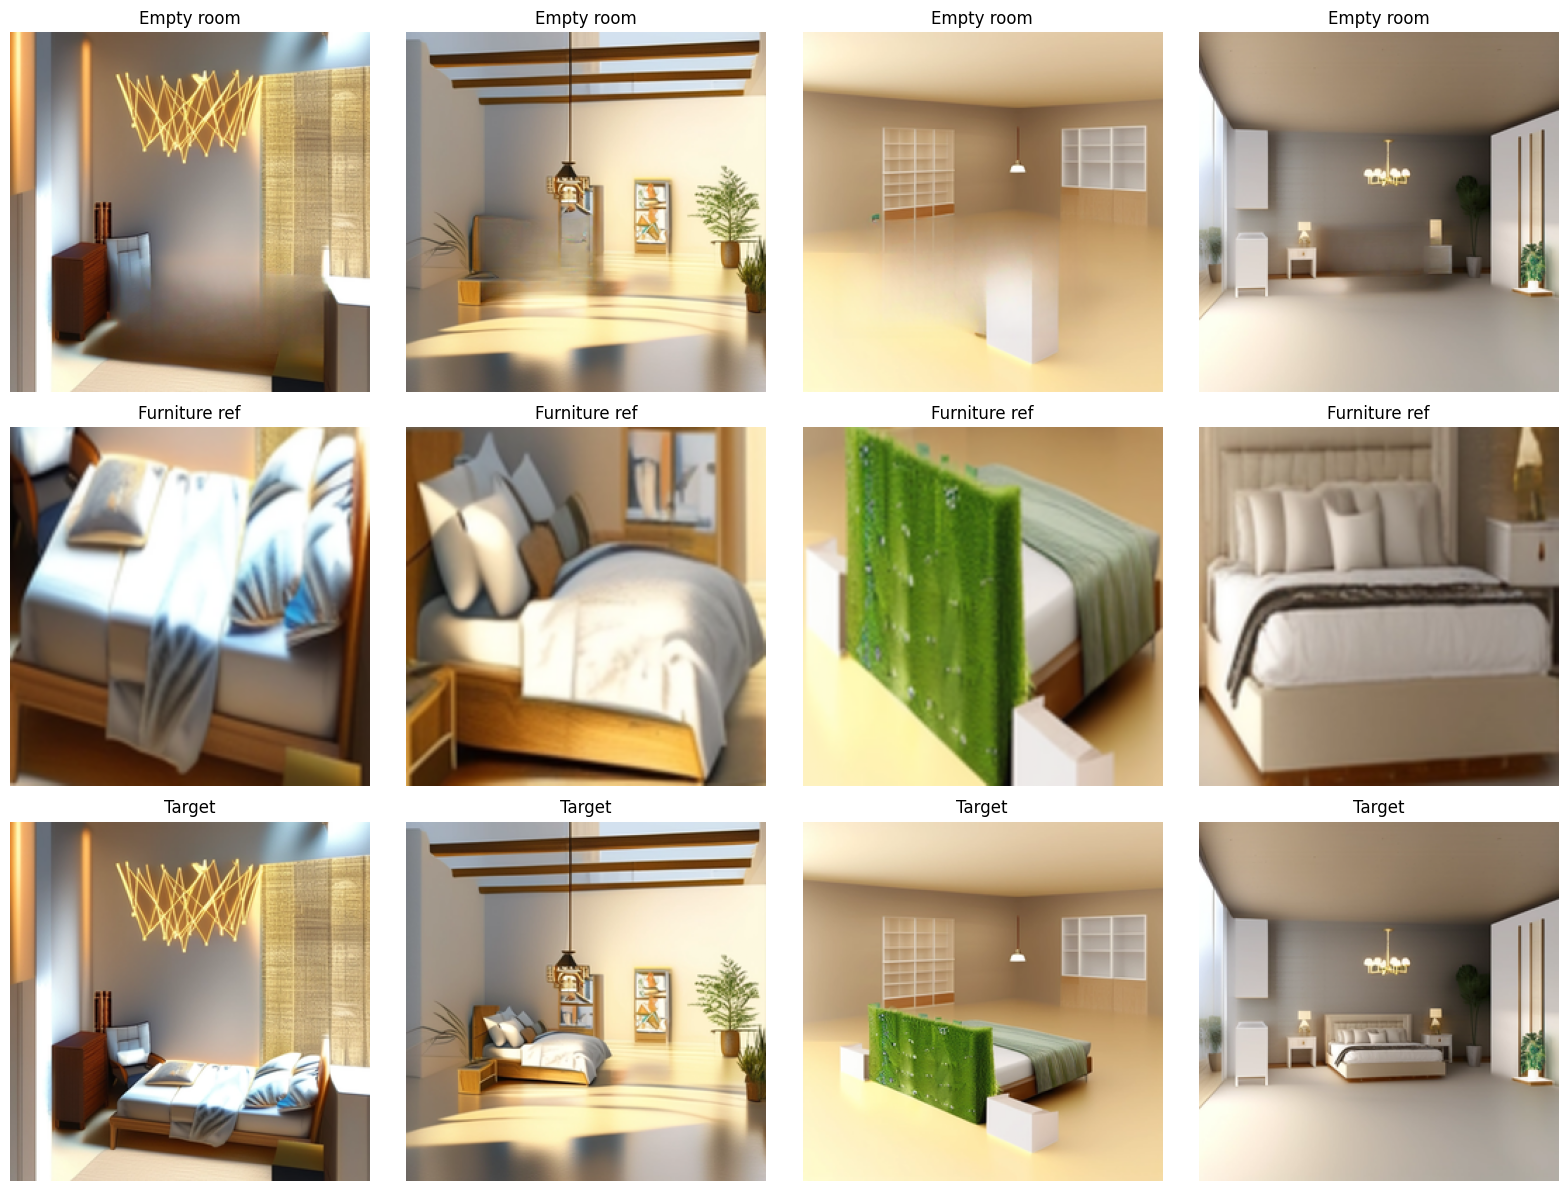

In [6]:
for room, target, furniture, bbox in train_ds.take(1):
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    for i in range(min(4, room.shape[0])):
        axes[0, i].imshow((room[i].numpy() + 1) / 2)
        axes[0, i].set_title('Empty room')
        axes[0, i].axis('off')
        axes[1, i].imshow((furniture[i].numpy() + 1) / 2)
        axes[1, i].set_title('Furniture ref')
        axes[1, i].axis('off')
        axes[2, i].imshow((target[i].numpy() + 1) / 2)
        axes[2, i].set_title('Target')
        axes[2, i].axis('off')
    plt.tight_layout()
    plt.show()

## Model Architecture

Four components:
1. **Reference Encoder** -- extracts furniture style vector (256-dim)
2. **Generator** -- U-Net encoder (room) + SPADE/AdaIN decoder
3. **Global Discriminator** -- PatchGAN on full image
4. **Local Discriminator** -- PatchGAN on cropped furniture region

In [7]:
WEIGHT_INIT = tf.keras.initializers.RandomNormal(stddev=0.02)


class InstanceNormalization(layers.Layer):
    def __init__(self, epsilon=1e-5, **kwargs):
        super().__init__(**kwargs)
        self.epsilon = epsilon

    def build(self, input_shape):
        ch = input_shape[-1]
        self.scale  = self.add_weight(name='scale',  shape=(ch,), initializer='ones')
        self.offset = self.add_weight(name='offset', shape=(ch,), initializer='zeros')

    def call(self, x):
        mean, var = tf.nn.moments(x, axes=[1, 2], keepdims=True)
        return self.scale * (x - mean) / tf.sqrt(var + self.epsilon) + self.offset


class SPADENorm(layers.Layer):
    """Spatially-Adaptive Denormalization conditioned on the room image."""
    def __init__(self, filters, **kwargs):
        super().__init__(**kwargs)
        self.filters = filters

    def build(self, input_shape):
        self.inst_norm   = InstanceNormalization()
        self.conv_shared = layers.Conv2D(128, 3, padding='same',
                                        kernel_initializer=WEIGHT_INIT, activation='relu')
        self.conv_gamma  = layers.Conv2D(self.filters, 3, padding='same',
                                        kernel_initializer=WEIGHT_INIT)
        self.conv_beta   = layers.Conv2D(self.filters, 3, padding='same',
                                        kernel_initializer=WEIGHT_INIT)

    def call(self, inputs):
        x, room_map = inputs
        normalized = self.inst_norm(x)
        room_resized = tf.image.resize(room_map, [tf.shape(x)[1], tf.shape(x)[2]])
        h = self.conv_shared(room_resized)
        gamma = self.conv_gamma(h)
        beta  = self.conv_beta(h)
        return normalized * (1.0 + gamma) + beta


class AdaIN(layers.Layer):
    """Adaptive Instance Normalization -- injects style vector into features."""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.epsilon = 1e-5

    def build(self, input_shape):
        ch = input_shape[0][-1]
        self.fc_gamma = layers.Dense(ch)
        self.fc_beta  = layers.Dense(ch)

    def call(self, inputs):
        x, style = inputs
        mean, var = tf.nn.moments(x, axes=[1, 2], keepdims=True)
        norm = (x - mean) / tf.sqrt(var + self.epsilon)
        gamma = self.fc_gamma(style)[:, tf.newaxis, tf.newaxis, :]
        beta  = self.fc_beta(style)[:, tf.newaxis, tf.newaxis, :]
        return norm * (1.0 + gamma) + beta


def downsample(filters, size=4, apply_norm=True, dropout=0.0):
    block = tf.keras.Sequential()
    block.add(layers.Conv2D(filters, size, strides=2, padding='same',
                            kernel_initializer=WEIGHT_INIT, use_bias=False))
    if apply_norm:
        block.add(InstanceNormalization())
    block.add(layers.LeakyReLU(0.2))
    if dropout > 0:
        block.add(layers.Dropout(dropout))
    return block

In [8]:
def build_reference_encoder(style_dim=STYLE_DIM):
    """CNN that extracts a global style vector from the furniture image."""
    inp = layers.Input(shape=[IMG_SIZE, IMG_SIZE, 3])
    x = inp
    for filters in [64, 128, 256, 512, 512]:
        x = layers.Conv2D(filters, 4, strides=2, padding='same',
                          kernel_initializer=WEIGHT_INIT, use_bias=False)(x)
        x = InstanceNormalization()(x)
        x = layers.LeakyReLU(0.2)(x)
    x = layers.GlobalAveragePooling2D()(x)
    style = layers.Dense(style_dim)(x)
    return tf.keras.Model(inp, style, name='reference_encoder')

In [9]:
def build_generator(style_dim=STYLE_DIM):
    """U-Net encoder (room) + SPADE/AdaIN decoder."""
    room_in  = layers.Input(shape=[IMG_SIZE, IMG_SIZE, 3], name='room')
    style_in = layers.Input(shape=[style_dim], name='style')

    # ---- Encoder (room image) ----
    down_stack = [
        downsample(64, apply_norm=False),
        downsample(128),
        downsample(256),
        downsample(512, dropout=0.5),
        downsample(512, dropout=0.5),
        downsample(512, dropout=0.5),
        downsample(512, dropout=0.5),
        downsample(512, apply_norm=False, dropout=0.5),
    ]

    x = room_in
    skips = []
    for down in down_stack:
        x = down(x)
        skips.append(x)
    skips = list(reversed(skips[:-1]))

    # ---- Bottleneck: inject furniture style ----
    x = AdaIN()([x, style_in])

    # ---- Decoder: SPADE (room-conditioned) + AdaIN (style) + skip connections ----
    up_filters = [512, 512, 512, 512, 256, 128, 64]
    for i, (filters, skip) in enumerate(zip(up_filters, skips)):
        x = layers.UpSampling2D()(x)
        x = layers.Conv2D(filters, 3, padding='same',
                          kernel_initializer=WEIGHT_INIT, use_bias=False)(x)
        x = SPADENorm(filters)([x, room_in])
        x = AdaIN()([x, style_in])
        x = layers.ReLU()(x)
        if i < 3:
            x = layers.Dropout(0.5)(x)
        x = layers.Concatenate()([x, skip])

    x = layers.UpSampling2D()(x)
    outputs = layers.Conv2D(3, 3, padding='same', activation='tanh',
                            kernel_initializer=WEIGHT_INIT)(x)

    return tf.keras.Model([room_in, style_in], outputs, name='generator')

In [10]:
SN = layers.SpectralNormalization


def build_global_discriminator():
    """PatchGAN with spectral norm. Returns [logits, feat1, feat2, feat3, feat4]."""
    cond = layers.Input(shape=[IMG_SIZE, IMG_SIZE, 6], name='condition')
    tar  = layers.Input(shape=[IMG_SIZE, IMG_SIZE, 3], name='target')
    x = layers.Concatenate()([cond, tar])

    feats = []
    for filters in [64, 128, 256]:
        x = SN(layers.Conv2D(filters, 4, strides=2, padding='same',
                              kernel_initializer=WEIGHT_INIT))(x)
        x = layers.LeakyReLU(0.2)(x)
        feats.append(x)

    x = layers.ZeroPadding2D()(x)
    x = SN(layers.Conv2D(512, 4, strides=1, kernel_initializer=WEIGHT_INIT))(x)
    x = layers.LeakyReLU(0.2)(x)
    feats.append(x)

    x = layers.ZeroPadding2D()(x)
    x = SN(layers.Conv2D(1, 4, strides=1, kernel_initializer=WEIGHT_INIT))(x)

    return tf.keras.Model([cond, tar], [x] + feats, name='disc_global')


def build_local_discriminator(crop_size=LOCAL_CROP):
    """Smaller PatchGAN with spectral norm. Returns [logits, feat1, feat2, feat3]."""
    inp = layers.Input(shape=[crop_size, crop_size, 3])
    x = inp

    feats = []
    for filters in [64, 128, 256]:
        x = SN(layers.Conv2D(filters, 4, strides=2, padding='same',
                              kernel_initializer=WEIGHT_INIT))(x)
        x = layers.LeakyReLU(0.2)(x)
        feats.append(x)

    x = SN(layers.Conv2D(1, 4, strides=1, padding='same',
                          kernel_initializer=WEIGHT_INIT))(x)

    return tf.keras.Model(inp, [x] + feats, name='disc_local')

In [11]:
def build_vgg_features():
    """VGG19 feature extractor for perceptual loss."""
    vgg = tf.keras.applications.VGG19(include_top=False, weights='imagenet')
    vgg.trainable = False
    layer_names = ['block1_conv1', 'block2_conv1', 'block3_conv1', 'block4_conv1']
    outputs = [vgg.get_layer(n).output for n in layer_names]
    return tf.keras.Model(vgg.input, outputs, name='vgg_features')


def perceptual_loss(vgg, fake, real):
    fake_pp = tf.keras.applications.vgg19.preprocess_input((fake + 1.0) * 127.5)
    real_pp = tf.keras.applications.vgg19.preprocess_input((real + 1.0) * 127.5)
    fake_feats = vgg(fake_pp)
    real_feats = vgg(real_pp)
    return tf.add_n([tf.reduce_mean(tf.abs(f - r)) for f, r in zip(fake_feats, real_feats)])

## Initialize Models

In [14]:
import json as _json

ref_encoder  = build_reference_encoder()
generator    = build_generator()
disc_global  = build_global_discriminator()
disc_local   = build_local_discriminator()
vgg          = build_vgg_features()

opt_g = tf.keras.optimizers.Adam(learning_rate=LR_G, beta_1=BETA1, beta_2=BETA2)
opt_d = tf.keras.optimizers.Adam(learning_rate=LR_D, beta_1=BETA1, beta_2=BETA2)

checkpoint = tf.train.Checkpoint(
    ref_encoder=ref_encoder, generator=generator,
    disc_global=disc_global, disc_local=disc_local,
    opt_g=opt_g, opt_d=opt_d,
)
ckpt_manager = tf.train.CheckpointManager(checkpoint, CHECKPOINT_DIR, max_to_keep=5)

HISTORY_PATH = os.path.join(CHECKPOINT_DIR, 'history.json')
START_EPOCH = 1
saved_history = None

if RESUME and ckpt_manager.latest_checkpoint:
    checkpoint.restore(ckpt_manager.latest_checkpoint)
    ckpt_name = os.path.basename(ckpt_manager.latest_checkpoint)
    ckpt_num = int(ckpt_name.split('-')[-1])
    START_EPOCH = ckpt_num * SAVE_EPOCH + 1
    print(f'Restored from {ckpt_manager.latest_checkpoint}  ->  resuming at epoch {START_EPOCH}')
    if os.path.isfile(HISTORY_PATH):
        try:
            with open(HISTORY_PATH) as f:
                saved_history = _json.load(f)
            print(f'Loaded loss history ({len(saved_history["g_loss"])} epochs)')
        except _json.JSONDecodeError:
            print(f'Warning: Could not load history from {HISTORY_PATH}. File might be corrupted. Starting new history.')
            saved_history = None
else:
    print('Starting fresh (RESUME=False or no checkpoint found)')

print(f'\nRef Encoder params:  {ref_encoder.count_params():,}')
print(f'Generator params:    {generator.count_params():,}')
print(f'Global Disc params:  {disc_global.count_params():,}')
print(f'Local Disc params:   {disc_local.count_params():,}')

Restored from /content/drive/MyDrive/693-project/checkpoints/spade_ref_tf/ckpt-7  ->  resuming at epoch 71

Ref Encoder params:  7,084,160
Generator params:    46,484,739
Global Disc params:  2,772,161
Local Disc params:   663,745


## Training

In [15]:
def _feat_match_loss(feats_fake, feats_real):
    """L1 distance between intermediate discriminator features."""
    return tf.add_n([tf.reduce_mean(tf.abs(ff - fr))
                     for ff, fr in zip(feats_fake, feats_real)])


@tf.function
def train_step(room, target, furniture, bbox):
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        style = ref_encoder(furniture, training=True)
        fake  = generator([room, style], training=True)

        # ---- Global discriminator ----
        cond = tf.concat([room, furniture], axis=-1)
        d_out_real_g = disc_global([cond, target], training=True)
        d_out_fake_g = disc_global([cond, fake], training=True)
        logit_real_g, *feats_real_g = d_out_real_g
        logit_fake_g, *feats_fake_g = d_out_fake_g

        # ---- Local discriminator (crop furniture region) ----
        batch_idx = tf.range(tf.shape(target)[0])
        real_crops = tf.image.crop_and_resize(target, bbox, batch_idx, [LOCAL_CROP, LOCAL_CROP])
        fake_crops = tf.image.crop_and_resize(fake,   bbox, batch_idx, [LOCAL_CROP, LOCAL_CROP])
        d_out_real_l = disc_local(real_crops, training=True)
        d_out_fake_l = disc_local(fake_crops, training=True)
        logit_real_l, *feats_real_l = d_out_real_l
        logit_fake_l, *feats_fake_l = d_out_fake_l

        # ---- Discriminator losses (Hinge) ----
        d_loss_global = 0.5 * (tf.reduce_mean(tf.nn.relu(1.0 - logit_real_g)) +
                               tf.reduce_mean(tf.nn.relu(1.0 + logit_fake_g)))
        d_loss_local  = 0.5 * (tf.reduce_mean(tf.nn.relu(1.0 - logit_real_l)) +
                               tf.reduce_mean(tf.nn.relu(1.0 + logit_fake_l)))
        d_loss = d_loss_global + d_loss_local

        # ---- Generator losses (Hinge + Feature Matching) ----
        g_loss_global = -tf.reduce_mean(logit_fake_g)
        g_loss_local  = -tf.reduce_mean(logit_fake_l)
        g_loss_l1     = tf.reduce_mean(tf.abs(fake - target))
        g_loss_perc   = perceptual_loss(vgg, fake, target)
        g_loss_feat   = (_feat_match_loss(feats_fake_g, feats_real_g) +
                         _feat_match_loss(feats_fake_l, feats_real_l))

        g_loss = (g_loss_global + g_loss_local +
                  LAMBDA_L1 * g_loss_l1 +
                  LAMBDA_PERC * g_loss_perc +
                  LAMBDA_FEAT * g_loss_feat)

    gen_vars  = ref_encoder.trainable_variables + generator.trainable_variables
    disc_vars = disc_global.trainable_variables + disc_local.trainable_variables

    gen_grads  = gen_tape.gradient(g_loss, gen_vars)
    disc_grads = disc_tape.gradient(d_loss, disc_vars)

    opt_g.apply_gradients(zip(gen_grads, gen_vars))
    opt_d.apply_gradients(zip(disc_grads, disc_vars))

    return g_loss, d_loss, g_loss_l1, g_loss_perc

In [16]:
def save_samples(epoch, n=4):
    for room, target, furniture, bbox in val_ds.take(1):
        style = ref_encoder(furniture[:n], training=False)
        fake  = generator([room[:n], style], training=False)

        room_vis   = (room[:n].numpy() + 1) / 2
        furn_vis   = (furniture[:n].numpy() + 1) / 2
        fake_vis   = np.clip((fake.numpy() + 1) / 2, 0, 1)
        target_vis = (target[:n].numpy() + 1) / 2

    fig, axes = plt.subplots(4, n, figsize=(4 * n, 16))
    for i in range(n):
        axes[0, i].imshow(room_vis[i]);   axes[0, i].set_title('Room');  axes[0, i].axis('off')
        axes[1, i].imshow(furn_vis[i]);   axes[1, i].set_title('Furn');  axes[1, i].axis('off')
        axes[2, i].imshow(fake_vis[i]);   axes[2, i].set_title('Gen');   axes[2, i].axis('off')
        axes[3, i].imshow(target_vis[i]); axes[3, i].set_title('GT');    axes[3, i].axis('off')
    plt.suptitle(f'Epoch {epoch}', fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(SAMPLE_DIR, f'epoch_{epoch:04d}.png'), dpi=100)
    plt.show()
    plt.close()


def update_lr(optimizer, epoch, initial_lr, num_epochs):
    decay_start = num_epochs // 2
    if epoch >= decay_start:
        new_lr = initial_lr * (1.0 - (epoch - decay_start) / (num_epochs - decay_start))
        optimizer.learning_rate.assign(max(new_lr, 1e-7))

In [ ]:
if saved_history is not None:
    history = saved_history
else:
    history = {'g_loss': [], 'd_loss': [], 'l1': [], 'perc': [], 'val_l1': []}

steps_per_epoch = len(train_df) // BATCH_SIZE
print(f'Training from epoch {START_EPOCH} to {NUM_EPOCHS}')

for epoch in range(START_EPOCH, NUM_EPOCHS + 1):
    eg, ed, el, ep = 0.0, 0.0, 0.0, 0.0
    nb = 0

    pbar = tqdm(train_ds, total=steps_per_epoch, desc=f'Epoch {epoch}/{NUM_EPOCHS}')
    for room, target, furniture, bbox in pbar:
        g, d, l1, perc = train_step(room, target, furniture, bbox)
        eg += g.numpy(); ed += d.numpy(); el += l1.numpy(); ep += perc.numpy()
        nb += 1
        pbar.set_postfix({'G': f'{g.numpy():.3f}', 'D': f'{d.numpy():.3f}'})

    history['g_loss'].append(float(eg/nb))
    history['d_loss'].append(float(ed/nb))
    history['l1'].append(float(el/nb))
    history['perc'].append(float(ep/nb))

    val_l1 = 0.0; nv = 0
    for vr, vt, vf, _ in val_ds:
        vs = ref_encoder(vf, training=False)
        vfake = generator([vr, vs], training=False)
        val_l1 += tf.reduce_mean(tf.abs(vfake - vt)).numpy()
        nv += 1
    history['val_l1'].append(float(val_l1 / max(nv, 1)))

    update_lr(opt_g, epoch, LR_G, NUM_EPOCHS)
    update_lr(opt_d, epoch, LR_D, NUM_EPOCHS)

    print(f'Epoch {epoch} | G: {history["g_loss"][-1]:.3f} | D: {history["d_loss"][-1]:.3f} | '
          f'L1: {history["l1"][-1]:.4f} | Perc: {history["perc"][-1]:.2f} | '
          f'Val L1: {history["val_l1"][-1]:.4f}')

    if epoch % SAMPLE_EPOCH == 0:
        save_samples(epoch)
    if epoch % SAVE_EPOCH == 0:
        ckpt_manager.save()
        with open(HISTORY_PATH, 'w') as f:
            _json.dump(history, f)
        print(f'  Checkpoint + history saved')

ckpt_manager.save()
with open(HISTORY_PATH, 'w') as f:
    _json.dump(history, f)
print('Training complete.')

Training from epoch 71 to 200


Epoch 71/200:   0%|          | 0/748 [00:00<?, ?it/s]

## Loss Curves

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(25, 4))
for ax, key, title in zip(axes, history.keys(),
        ['Generator', 'Discriminator', 'Train L1', 'Perceptual', 'Val L1']):
    ax.plot(history[key])
    ax.set_title(title)
    ax.set_xlabel('Epoch')
plt.tight_layout()
plt.savefig(os.path.join(SAMPLE_DIR, 'loss_curves.png'), dpi=150)
plt.show()

## Evaluation

In [ ]:
all_ssim, all_psnr = [], []
fid_real_dir = os.path.join(SAMPLE_DIR, 'fid_real')
fid_fake_dir = os.path.join(SAMPLE_DIR, 'fid_fake')
os.makedirs(fid_real_dir, exist_ok=True)
os.makedirs(fid_fake_dir, exist_ok=True)

idx = 0
for room, target, furniture, _ in tqdm(test_ds, desc='Evaluating'):
    style = ref_encoder(furniture, training=False)
    fake  = generator([room, style], training=False)
    f01 = (fake + 1) / 2
    t01 = (target + 1) / 2
    all_ssim.extend(tf.image.ssim(f01, t01, 1.0).numpy().tolist())
    all_psnr.extend(tf.image.psnr(f01, t01, 1.0).numpy().tolist())
    for j in range(f01.shape[0]):
        ri = tf.cast(tf.clip_by_value(t01[j]*255, 0, 255), tf.uint8)
        fi = tf.cast(tf.clip_by_value(f01[j]*255, 0, 255), tf.uint8)
        tf.io.write_file(os.path.join(fid_real_dir, f'{idx:05d}.png'), tf.image.encode_png(ri))
        tf.io.write_file(os.path.join(fid_fake_dir, f'{idx:05d}.png'), tf.image.encode_png(fi))
        idx += 1

print(f'\n===== SPADE+Ref Test Metrics =====')
print(f'  SSIM: {np.mean(all_ssim):.4f}')
print(f'  PSNR: {np.mean(all_psnr):.2f} dB')
print(f'===================================')

In [ ]:
!pip install pytorch-fid -q
!python -m pytorch_fid {fid_real_dir} {fid_fake_dir}

## Side-by-Side Comparison

In [ ]:
for room, target, furniture, _ in test_ds.take(1):
    n = min(8, room.shape[0])
    style = ref_encoder(furniture[:n], training=False)
    fake  = generator([room[:n], style], training=False)

    rv = (room[:n].numpy() + 1) / 2
    fv = (furniture[:n].numpy() + 1) / 2
    tv = (target[:n].numpy() + 1) / 2
    gv = np.clip((fake.numpy() + 1) / 2, 0, 1)

fig, axes = plt.subplots(n, 4, figsize=(20, 4.5 * n))
titles = ['Empty Room', 'Furniture Ref', 'Ground Truth', 'Generated']
for i in range(n):
    axes[i, 0].imshow(rv[i])
    axes[i, 1].imshow(fv[i])
    axes[i, 2].imshow(tv[i])
    axes[i, 3].imshow(gv[i])
    ssim = tf.image.ssim(tf.constant(gv[i:i+1]), tf.constant(tv[i:i+1]), 1.0).numpy()[0]
    psnr = tf.image.psnr(tf.constant(gv[i:i+1]), tf.constant(tv[i:i+1]), 1.0).numpy()[0]
    axes[i, 3].set_xlabel(f'SSIM: {ssim:.3f} | PSNR: {psnr:.1f}', fontsize=10)
    for j in range(4):
        axes[i, j].axis('off')
        if i == 0:
            axes[i, j].set_title(titles[j], fontsize=14, fontweight='bold')

plt.suptitle('SPADE + Ref Encoder -- Test Results', fontsize=18, fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig(os.path.join(SAMPLE_DIR, 'comparison_results.png'), dpi=150, bbox_inches='tight')
plt.show()